# 4D-STEM DPC disk tracking -- center of mass method

## Code by Pravan Chakravarthy & Dan Durham (2026)

This code uses the center of mass method to detect disk shifts from 4D-STEM DPC data.

Associated package `dpc4dstem` must be installed (or available as a sub-directory in the same folder as this notebook). Other dependencies include: `matplotlib`, `numpy`, `ncempy`

This code uses ellipse coordinate functions from a legacy verison of py4DSTEM (0.13.7) but this currently does not need to be installed.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

from operator import sub

import ncempy.io as nio 

import dpc4dstem as dpc4d

%matplotlib inline

In [2]:
plt.style.use('seaborn-v0_8-poster')

## Prepare 4D data

In [3]:
# Set the filename to read
filename = "disk_velox"
filepath_input = "input/" + filename + ".mrc"
sample_shape = '_'+filename[:4]

if sample_shape == '_disk':
    R_Ny = 128
    R_Nx = 128
elif sample_shape == '_rect':
    R_Ny = 99
    R_Nx = 157
    
scan_shape = (R_Ny,R_Nx)

with nio.mrc.fileMRC(filepath_input) as f:
    dataset_shape_raw = f.dataSize
    R_N = dataset_shape_raw[0]
    Q_Ny = dataset_shape_raw[1]
    Q_Nx = dataset_shape_raw[2]

if ~(R_N == R_Ny*R_Nx):
    print('WARNING: Scan shape provided is inconsistent with number of frames')
    
# Prepare coordinate arrays
Qx,Qy = np.meshgrid(np.arange(Q_Nx),np.arange(Q_Ny))
    
dataset_shape_4D = (R_Ny,R_Nx,int(Q_Ny),int(Q_Nx))
print('Dataset shape: ' + str(dataset_shape_4D))


Dataset shape: (128, 128, 256, 256)


# Initialize CoM and disk shape using vacuum disk

### Load vac probe

([], [])

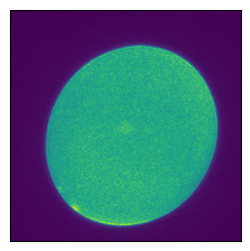

In [4]:
ind_vac = (0,0)
imdata = dpc4d.io.load_single_mrc_frame(filepath_input,ind_vac,scan_shape=scan_shape)

plt.figure(figsize=(3,3))
plt.imshow(imdata)
plt.xticks([])
plt.yticks([])

### Compute CoM

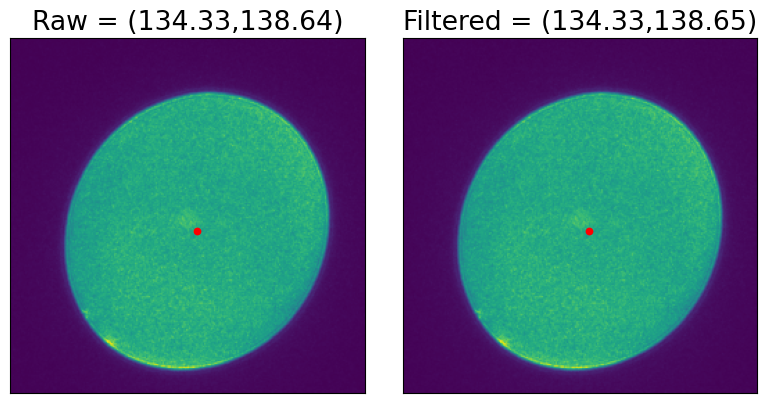

In [5]:
# Filter the disk image
k_thresh = 50
filt_sigma = 0

imfilt = np.zeros(imdata.shape)
imfilt[:] = imdata[:]
if filt_sigma>0:
    imfilt = gaussian_filter(imdata,filt_sigma)
imfilt = imfilt*(imfilt>k_thresh)

# Compute CoM for original and filtered image
CoM_0 = dpc4d.process.compute_CoM(imdata,Qx,Qy)
CoM_0_disp = ["{:.2f}".format(val) for val in CoM_0]
CoM_0_filt = dpc4d.process.compute_CoM(imfilt,Qx,Qy)
CoM_0_filt_disp = ["{:.2f}".format(val) for val in CoM_0_filt]

imlist = [imdata,imfilt]
CoM_list = [CoM_0,CoM_0_filt]
CoM_disp_list = [CoM_0_disp,CoM_0_filt_disp]
title_list = ['Raw','Filtered']

plt.figure(figsize=(8,4))
for i_plot in range(2):
    CoM = CoM_list[i_plot]
    CoM_disp = CoM_disp_list[i_plot]
    
    plt.subplot(1,2,i_plot+1)
    plt.imshow(imlist[i_plot])
    
    plt.plot(CoM[0],CoM[1],'r.')
    plt.xticks([])
    plt.yticks([])
    plt.title(title_list[i_plot]+' = ' + '(' + CoM_disp[0] + ',' + CoM_disp[1] + ')' )

plt.tight_layout()

### Subtract each CoM from vacuum point (0,0) to get the CoM shifts for each pixel

In [6]:
CoM_array = [[None for _ in range(R_Nx)] for _ in range(R_Ny)]
CoM_difference = [[None for _ in range(R_Nx)] for _ in range(R_Ny)]

for i in range(R_Ny):
    for j in range(R_Nx):
        index = (i, j)
        image = dpc4d.io.load_single_mrc_frame(filepath_input, index, scan_shape=scan_shape)
        CoM_array[i][j] = dpc4d.process.compute_CoM(image, Qx, Qy)
        CoM_difference[i][j] = tuple(a - b for a, b in zip(CoM_array[i][j], CoM_0))

np.save('output/CoM'+sample_shape+'_shift_map.npy',CoM_difference)

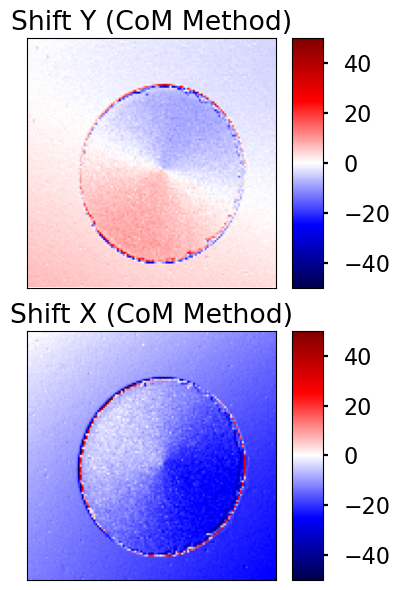

In [7]:
# Plot the resulting shifts
dpc4d.visualize.plot_diff_maps([np.array(CoM_difference)[:,:,0],np.array(CoM_difference)[:,:,1]],['Shift Y (CoM Method)','Shift X (CoM Method)'],4,6,clim=(-50,50))

plt.savefig('output/CoM' + sample_shape + '_shift_visualization.png')